# Bell circuit and SWAP test

## 1. Computational basis and normalization

**Required convention:** $|q_0 q_1\rangle$ ordering, with $q_0$ as the most significant bit (MSB). The basis $|00\rangle, |01\rangle, |10\rangle, |11\rangle$ corresponds to indices `0, 1, 2, 3`.

The assignment provides `ket00()` and `normalize()`, along with a check of the initial state's norm.

**TODO — required explanation:** briefly describe the basis ordering and the mapping between bitstrings and indices.

In [ ]:
import numpy as np
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister
from qiskit.circuit import ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

DTYPE = np.complex128

def ket00():
    """Return |00> as a length‑4 complex column vector."""
    v = np.zeros(4, dtype=DTYPE)
    v[0] = 1.0
    return v

def normalize(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v)
    if n == 0:
        raise ValueError("Zero vector cannot be normalized.")
    return v / n

# Example
psi = ket00()
assert np.isclose(np.linalg.norm(psi), 1.0)

**Description of the convention:**

TODO — write here.

## 2. Gates and their application to the state

Provided code: identity, Hadamard, CNOT with control $q_0$ and target $q_1$, expansion of a 1-qubit gate, and matrix-vector application. The assignment's unitarity checks are included.

**TODO — required explanation:** briefly justify the CNOT control/target convention with respect to the basis ordering.

In [10]:
# 1‑qubit and 2‑qubit gate definitions (matrix form)
I2 = np.array([[1, 0], [0, 1]], dtype=DTYPE)
H  = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=DTYPE)

# CNOT with control = q0 (MSB), target = q1 (LSB) in basis |q0 q1>
CNOT_01 = np.array([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,0,1],
    [0,0,1,0]
], dtype=DTYPE)

# Expand a 1‑qubit unitary U to a 2‑qubit operator acting on target qubit t in |q0 q1> order
# t = 0 applies to q0 (MSB); t = 1 applies to q1 (LSB)

def expand_1q(U: np.ndarray, t: int) -> np.ndarray:
    if t == 0:   # act on q0 (MSB)
        return np.kron(U, I2)
    elif t == 1: # act on q1 (LSB)
        return np.kron(I2, U)
    else:
        raise ValueError("target index must be 0 or 1")

# Apply a gate matrix to a state vector

def apply(U: np.ndarray, psi: np.ndarray) -> np.ndarray:
    return U @ psi

# Quick unit tests
assert np.allclose(H.conj().T @ H, I2)
assert np.allclose(CNOT_01.conj().T @ CNOT_01, np.eye(4))

**Justification of the CNOT convention:**

TODO — write here.

## 3. Bell circuit

Required sequence: initialize in $|00\rangle$, apply Hadamard to $q_0$, then apply CNOT($q_0\rightarrow q_1$).

**TODO — required check:** print the final state and confirm that it matches $(|00\rangle + |11\rangle)/\sqrt{2}$ up to a global phase.

In [11]:
def bell_state() -> np.ndarray:
    psi = ket00()
    # H on q0 (MSB), then CNOT(control=q0, target=q1)
    psi = apply(expand_1q(H, t=0), psi)
    psi = apply(CNOT_01, psi)
    return normalize(psi)

psi_bell = bell_state()
print("Bell state vector:", np.round(psi_bell, 6))
# Expected amplitudes (up to a global phase): [1/√2, 0, 0, 1/√2]

Bell state vector: [0.707107+0.j 0.      +0.j 0.      +0.j 0.707107+0.j]


In [12]:
assert np.allclose(psi_bell, [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])

**Confirmation and discussion of the final state:**

It matches 

## 4. Measurements and histogram

The provided code samples `10_000` measurements with default seed `7` and creates the histogram.

**TODO — required comparison:** assess whether the counts match expectations within sampling error, and compare them with the earlier work referenced in the assignment.

{'00': 4983, '01': 0, '10': 0, '11': 5017}


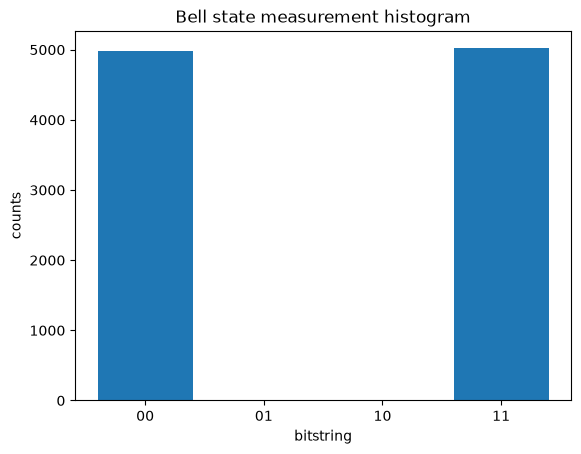

In [13]:
import matplotlib.pyplot as plt

BITSTR = ["00","01","10","11"]

def sample_bitstrings(psi: np.ndarray, shots: int = 10_000, seed: int = 7):
    rng = np.random.default_rng(seed)
    probs = np.abs(psi)**2
    idx = rng.choice(4, size=shots, p=probs)
    return idx

# Sample from Bell state
shots = 10_000
idx = sample_bitstrings(psi_bell, shots=shots)

# Make histogram
counts = {b: int(np.sum(idx == i)) for i, b in enumerate(BITSTR)}
print(counts)
plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstring"); plt.ylabel("counts"); plt.title("Bell state measurement histogram")
plt.show()

**Comparison of counts and reflection:**

TODO — write based on the observed results and earlier work.

## 5. Circle notation

**TODO — required visualization:** use the lecture function to visualize `psi_bell`.

[Canvas reference provided in the assignment](https://canvas.kth.se/courses/63895/pages/1-dot-1-1-python-code-for-circle-notation?module_item_id=1539607).

The function is not included in the supplied text: this section remains to be completed using the course materials.

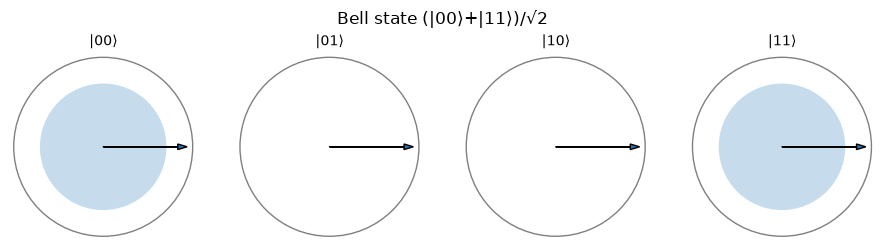

In [ ]:
def sv_from_circ(circ: QuantumCircuit) -> np.ndarray:
    sv = Statevector(circ)
    return np.asarray(sv, dtype=np.complex128)

class QubitSystem:
    def __init__(self, statevector: np.ndarray, label: str = "Qubit System"):
        self.label = label
        self.set_statevector(statevector)

    def set_statevector(self, statevector: np.ndarray):
        sv = np.asarray(statevector, dtype=np.complex128).flatten()
        if sv.ndim != 1:
            raise ValueError("Statevector must be 1D.")
        n_states = sv.size
        n_qubits = int(round(math.log2(n_states)))
        if 2**n_qubits != n_states:
            raise ValueError("Length must be a power of 2.")
        # Defensive normalization (harmless if already normalized)
        norm = np.linalg.norm(sv)
        if norm != 0 and not np.isclose(norm, 1.0):
            sv = sv / norm

        self.n_qubits = n_qubits
        self.n_states = n_states
        self.amps  = sv
        self.prob  = np.abs(sv)**2
        self.phase = np.angle(sv)

    def viz_circle(self, max_cols: int = 8, figsize_scale: float = 2.3):
        cols = max(1, min(max_cols, self.n_states))
        rows = int(math.ceil(self.n_states / cols))

        fig, axes = plt.subplots(
            rows, cols,
            figsize=(cols*figsize_scale, rows*(figsize_scale+0.2))
        )
        axes = np.atleast_2d(axes)

        def bitstr(i: int, n: int) -> str:
            return format(i, f"0{n}b")

        for idx in range(rows * cols):
            r, c = divmod(idx, cols)
            ax = axes[r, c]
            ax.set_aspect("equal")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.axis("off")

            if idx >= self.n_states:
                ax.set_visible(False)
                continue

            # Outer reference circle
            ax.add_patch(plt.Circle((0.5, 0.5), 0.48, fill=False, lw=1.0, alpha=0.5))

            # Filled disk: radius ∝ sqrt(probability) so area ∝ probability
            radius = 0.48 * np.sqrt(self.prob[idx])
            ax.add_patch(plt.Circle((0.5, 0.5), radius, alpha=0.25))

            # Phase arrow
            angle = self.phase[idx]
            L = 0.45
            x2 = 0.5 + L * np.cos(angle)
            y2 = 0.5 + L * np.sin(angle)
            ax.arrow(0.5, 0.5, x2 - 0.5, y2 - 0.5,
                     head_width=0.03, head_length=0.05, length_includes_head=True)

            ax.set_title(f"|{bitstr(idx, self.n_qubits)}⟩", fontsize=10)

        fig.suptitle(self.label, fontsize=12)
        plt.tight_layout()
        plt.show()

QubitSystem(sv_from_circ(psi_bell), label="Bell state (|00⟩+|11⟩)/√2").viz_circle()

**Interpretation of circle notation:**

TODO — explain how the plot represents the two components $|00\rangle$ and $|11\rangle$ and their relative phase.

## 6. SWAP test: setup

Objective: estimate the fidelity between two pure 1-qubit states and compare it with the direct inner product.

**Required convention:** $|\mathrm{output}\ A_0\ B_0\rangle$ ordering, with `output` as the MSB. Indices `0..3` have `output=0`; indices `4..7` have `output=1`.

The pasted text is missing the formulas after “Fidelity (pure states)” and “In the SWAP test”. The provided code snippets are preserved below.

Helpers provided in the assignment:

In [17]:
def expand_1q_n(U: np.ndarray, t: int, n: int) -> np.ndarray:
    op = np.array([[1]], dtype=U.dtype)
    for q in range(n):
        op = np.kron(op, U if q == t else I2)
    return op

# Apply CSWAP, with ancilla as control
P0 = np.array([[1,0],[0,0]], dtype=DTYPE)  # |0><0| on ancilla
P1 = np.array([[0,0],[0,1]], dtype=DTYPE)  # |1><1| on ancilla
SWAP_A0_B0 = np.array([
    [1,0,0,0],
    [0,0,1,0],
    [0,1,0,0],
    [0,0,0,1]
], dtype=DTYPE)  # SWAP on A0 and B0
CSWAP = (np.kron(P0, np.eye(4)) + np.kron(P1, SWAP_A0_B0)) # CSWAP with ancilla as control

### 6.1. Input states

**TODO:** define `psi` and `phi` as normalized complex 1-qubit vectors (length 2).

**Execution order:** the variable `psi` from section 1 contains a **2-qubit** state. Before using the SWAP snippets below, redefine `psi` and define `phi` for the **1-qubit** case under study.

Sections 6.2–6.5 present the original code as a Markdown reference. Their corresponding code cells are left to be completed, so these snippets are not executed before the inputs have been prepared.

In [20]:
psi = np.array([1, 0], dtype=DTYPE)
phi = np.array([0, 1], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)
init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi))  
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()   # indices with output=1
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)

assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

######################
psi = np.array([1, 0], dtype=DTYPE)
phi = np.array([1, 0], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)

init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi))  
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()   
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)
assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

######################
psi = np.array([1, 1], dtype=DTYPE) / np.sqrt(2)
phi = np.array([1, 0], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)

init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi)) 
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()  
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)
assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

4.440892098500626e-16 0.0
1.0 1.0
0.5000000000000002 0.5000000000000001


# Bonus 1

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator


def fidelity(u, v):
    u = u / np.linalg.norm(u)
    v = v / np.linalg.norm(v)
    return float(np.abs(np.vdot(u, v))**2)


def build_swap_test(k):
    n = 3
    reference_k = 5  # |101>
    reference = QuantumRegister(n, "reference")
    test = QuantumRegister(n, "test")
    output = QuantumRegister(1, "output")
    result = ClassicalRegister(1, "result")
    circuit = QuantumCircuit(reference, test, output, result)

    # Register index 0 is the least significant bit in Qiskit.
    for i in range(n):
        if (reference_k >> i) & 1:
            circuit.x(reference[i])
        if (k >> i) & 1:
            circuit.x(test[i])

    circuit.h(output[0])
    for i in range(n):
        circuit.ccx(output[0], reference[i], test[i])
        circuit.ccx(output[0], test[i], reference[i])
        circuit.ccx(output[0], reference[i], test[i])
    circuit.h(output[0])
    circuit.measure(output[0], result[0])
    return circuit


In [90]:
simulator = AerSimulator()
for k in [5, 0]:
    circuit = transpile(build_swap_test(k), simulator)
    counts = simulator.run(circuit, shots=10000, seed_simulator=7).result().get_counts()
    p1 = counts.get("1", 0) / 10000
    estimated = 1 - 2 * p1
    expected = 1 if k == 5 else 0
    print("k =", k, "Estimated fidelity:", round(estimated, 3), "Expected:", expected)
    assert np.isclose(expected, estimated, atol=0.01)

k = 5 Estimated fidelity: 1.0 Expected: 1
k = 0 Estimated fidelity: 0.002 Expected: 0
